In [24]:
# jax-metal is broken with JAX 0.5.1+; force CPU backend
import os
os.environ["JAX_PLATFORMS"] = "cpu"

from functools import partial

import dynamiqs as dq
import jax.numpy as jnp
import jax
from jax import Array
from jax.random import normal, PRNGKey
import optax

import qontrol as ql
# from qontrol.plot import plot_controls

jax.config.update("jax_enable_x64", False)

In [25]:
d_qudit = 4
d_qubit = 2
d_total = d_qudit * d_qubit

hyperparams = {
    "TOTAL_TIME": 10, # gate duration
    "DT": 0.01, # time step
    "MAX_AMP": 1.0, # max amplitude of controls
    "SEED_AMP": 0.1, # amplitude of seed pulse
    "LEARNING_RATE": 0.01, # learning rate for optimizer
    "ITERATIONS": 100, # number of optimization steps
    "TARGET_FIDELITY": 0.99, # target fidelity
}

In [26]:
def ketbra(i, j, d):
    return dq.basis(d, i) @ dq.basis(d, j).dag()

def generate_spin_operators(s) -> tuple:
    """
    Generate all spin operators up to a global phase factor.
    
    Args:
        s: spin quantum number
    """
    d = int(2*s + 1)
    m_vals = jnp.array([s - k for k in range(d)])
    Sz = jnp.diag(m_vals.astype(jnp.complex64))

    # S+
    sp_diag = jnp.array([
        jnp.sqrt(s * (s + 1) - m_vals[k+1] * (m_vals[k+1] + 1))
        for k in range(d-1)
    ]).astype(jnp.complex64)
    Sp = jnp.diag(sp_diag, k = 1)
    Sm = Sp.conj().T

    Sx = (Sp + Sm) / 2
    Sy = (Sp - Sm) / (2j)
    S = jnp.sqrt(Sx @ Sx + Sy @ Sy + Sz @ Sz)

    return Sx, Sy, Sz, S

# get spin operators
s = 3/2
Sx, Sy, Sz, S = generate_spin_operators(s)
spin_ops = [Sx, Sy, Sz]
spin_labels = [r"S_x", r"S_y", r"S_z"]

# get pauli matrices
sx = jnp.array([[0, 1], [1, 0]], dtype=jnp.complex64)
sy = jnp.array([[0, -1j], [1j, 0]], dtype=jnp.complex64)
sz = jnp.array([[1, 0], [0, -1]], dtype=jnp.complex64)
pauli_ops = [sx, sy, sz]
pauli_labels = [r"\sigma_x", r"\sigma_y", r"\sigma_z"]

# identities
I2 = jnp.eye(2, dtype=jnp.complex64)
I4 = jnp.eye(4, dtype=jnp.complex64)

# check commutation relations
assert jnp.allclose(Sx @ Sy - Sy @ Sx, 1j * Sz)
assert jnp.allclose(Sx @ Sz - Sz @ Sx, -1j * Sy)
assert jnp.allclose(Sy @ Sz - Sz @ Sy, 1j * Sx)

# check that Sx^2 + Sy^2 + Sz^2 = s(s+1) I
assert jnp.allclose(S @ S, s * (s + 1) * jnp.eye(4))

In [27]:
H_qudit_1_body = [jnp.kron(I2, S) for S in [Sx, Sy, Sz]]
labels_qudit_1_body = [fr"$I_2 \otimes {S}$" for S in spin_labels]

H_qubit_1_body = [jnp.kron(s, I4) for s in [sx, sy, sz]]
labels_qubit_1_body = [fr"${s} \otimes I_4$" for s in pauli_labels]

H_coupled = []
labels_coupled = []
for i, Si in enumerate([Sx, Sy, Sz]):
    for j, sj in enumerate([sx, sy, sz]):
        H_coupled.append(jnp.kron(sj, Si))
        labels_coupled.append(fr"${pauli_labels[j]} \otimes {spin_labels[i]}$")

H1_full = H_qudit_1_body + H_qubit_1_body + H_coupled
labels_full = labels_qudit_1_body + labels_qubit_1_body + labels_coupled
n_controls = len(H1_full)

print(f"1 body qubit controls ({len(labels_qubit_1_body)}): {labels_qubit_1_body}")
print(f"1 body qudit controls ({len(labels_qudit_1_body)}): {labels_qudit_1_body}")
print(f"2 body controls ({len(labels_coupled)}): {labels_coupled}")
print(f"Total controls: {n_controls}")

# verify that each is hermitian
for k, (H, label) in enumerate(zip(H1_full, labels_full)):
    assert jnp.allclose(H, H.conj().T)

1 body qubit controls (3): ['$\\sigma_x \\otimes I_4$', '$\\sigma_y \\otimes I_4$', '$\\sigma_z \\otimes I_4$']
1 body qudit controls (3): ['$I_2 \\otimes S_x$', '$I_2 \\otimes S_y$', '$I_2 \\otimes S_z$']
2 body controls (9): ['$\\sigma_x \\otimes S_x$', '$\\sigma_y \\otimes S_x$', '$\\sigma_z \\otimes S_x$', '$\\sigma_x \\otimes S_y$', '$\\sigma_y \\otimes S_y$', '$\\sigma_z \\otimes S_y$', '$\\sigma_x \\otimes S_z$', '$\\sigma_y \\otimes S_z$', '$\\sigma_z \\otimes S_z$']
Total controls: 15


In [28]:
def lie_algebra_dimension(generators_jnp, max_depth=8, tol=1e-10):
    """
    Compute the dimension of the Lie algebra generated by the given generators.
    This is done by iterating commutators of {iH_k} with {H_k}

    Returns:
        The number of linearly indepedent elements in the Lie algebra found.
    """

    d = generators_jnp[0].shape[0]

    # get anti-Hermitian generators
    generators_anti_hermitian = [1j * g for g in generators_jnp]

    def hilbert_schmidt_inner_product(A, B):
        """
        Compute the Hilbert-Schmidt inner product of two matrices.
        """
        return jnp.trace(A.conj().T @ B).real
    
    def orthogonalize_with_basis(operator, basis):
        """
        Orthogonalize the operator with respect to the basis.
        """
        for b in basis:
            operator = operator - hilbert_schmidt_inner_product(b, operator) * b
        return operator

    basis = []
    for g in generators_anti_hermitian:
        g_orth = orthogonalize_with_basis(g, basis)
        norm = jnp.sqrt(jnp.abs(hilbert_schmidt_inner_product(g_orth, g_orth)))
        if norm > tol:
            basis.append(g_orth / norm)
    
    target = d * d - 1
    for depth in range(1, max_depth + 1):
        n_before = len(basis)
        for i in range(len(basis)):
            for j in range(i + 1, len(basis)):
                comm = basis[i] @ basis[j] - basis[j] @ basis[i]
                comm_orth = orthogonalize_with_basis(comm, basis)
                norm = jnp.sqrt(jnp.abs(hilbert_schmidt_inner_product(comm_orth, comm_orth)))
                if norm > tol:
                    basis.append(comm_orth / norm)
                    if len(basis) >= target:
                        return len(basis)
        if len(basis) == n_before:
            print(f"converged at depth {depth}")
            break

    return len(basis)

rank = lie_algebra_dimension(H1_full)
target = d_total * d_total - 1

# Quantum Optimal Control

---

Find a beginning operator state and target operator state which show full controllability of the qudit

## Setup

---

In [29]:
n_timesteps = int(hyperparams["TOTAL_TIME"] / hyperparams["DT"])
tsave = jnp.linspace(0, hyperparams["TOTAL_TIME"], n_timesteps + 1)

# drift hamiltonian setup
omega0 = 2 * jnp.pi * 5 # GHz, base frequency
alpha = 2 * jnp.pi * (-0.2) # GHz, anharmonicity
m_vals = jnp.array([1.5, 0.5, -0.5, -1.5])
H0_qudit = jnp.diag((omega0 * m_vals + alpha * m_vals**2).astype(jnp.complex64))
omega_qubit = 2 * jnp.pi * 5.19 # GHz, qubit frequency
H0_qubit = 0.5 * omega_qubit * sz

H0_jax = jnp.kron(H0_qubit, I4) + jnp.kron(I2, H0_qudit)

H0 = dq.asqarray(H0_jax)
H1_list_dq = [dq.asqarray(H) for H in H1_full]

In [30]:
def H_pwc(drive_parameters):
    """
    Construct the time-dependent hamiltonian with clipped amplitudes for the controls

    $$
    H(t) = H0 + \\sum_k clip(u_k(t)) H_k
    $$

    Args:
        drive_parameters: shape (n_controls, n_timesteps)
    
    Returns:
        TimeQArray for use in dq.sesolve
    """
    scaled_controls = jnp.tanh(drive_parameters)

    H = H0
    for i, H1 in enumerate(H1_list_dq):
        H += dq.pwc(tsave, scaled_controls[i], H1)
    return H


In [31]:
key = jax.random.PRNGKey(42)
Z = (jax.random.normal(key, (d_total, d_total)) + 1j * jax.random.normal(key, (d_total, d_total))) / jnp.sqrt(2 * d_total) # random jnp.complex64 matrix
U, _ = jnp.linalg.qr(Z) # jnp.complex64 QR decomposition to yield an arbitrary unitary
U = U.astype(jnp.complex64)

phase = jnp.linalg.det(U)
U_target = U * (phase.conj()) ** (1 / d_total) # fix global phase
print(f"Target unitary:\n{U_target @ U_target.conj().T = }")
assert jnp.allclose(U_target @ U_target.conj().T, jnp.eye(d_total), rtol=1e-4, atol=1e-6)

print(f"Target unitary:\n{U_target}")

Target unitary:
U_target @ U_target.conj().T = Array([[ 1.0000002e+00+0.0000000e+00j, -1.9847757e-08+1.1279395e-08j,
        -1.8167228e-09-2.3658856e-08j,  6.9918855e-08-5.2195546e-08j,
        -1.0419782e-08-5.0418599e-08j, -6.2651935e-08+3.5139749e-09j,
        -3.4447268e-08+4.5065466e-08j,  2.3084738e-08+2.6167250e-08j],
       [-1.9847757e-08-1.1279395e-08j,  1.0000002e+00+0.0000000e+00j,
         2.6453781e-09-1.4517550e-08j, -3.1274190e-08+1.1775401e-08j,
         4.7998746e-08+8.0094136e-09j,  4.5037119e-08-1.5717555e-08j,
        -6.1561636e-09-4.2345704e-08j, -3.7549050e-08-2.9396499e-08j],
       [-1.8167228e-09+2.3658856e-08j,  2.6453781e-09+1.4517550e-08j,
         1.0000001e+00+0.0000000e+00j,  4.8172765e-08+2.9379899e-08j,
        -3.7909739e-08-2.5377531e-09j, -1.2522310e-08+1.0388554e-08j,
         3.8665760e-08+4.7257835e-08j,  4.8935345e-08+5.2079240e-08j],
       [ 6.9918855e-08+5.2195546e-08j, -3.1274190e-08-1.1775401e-08j,
         4.8172765e-08-2.9379899e-08j,  

In [32]:
initial_states = [dq.basis(d_total, i) for i in range(d_total)]

target_states = []
for k in range(d_total):
    psi0 = jnp.zeros((d_total, 1), dtype=jnp.complex64)
    psi0 = psi0.at[k, 0].set(1)
    target_states.append(psi0)

## GRAPE

---

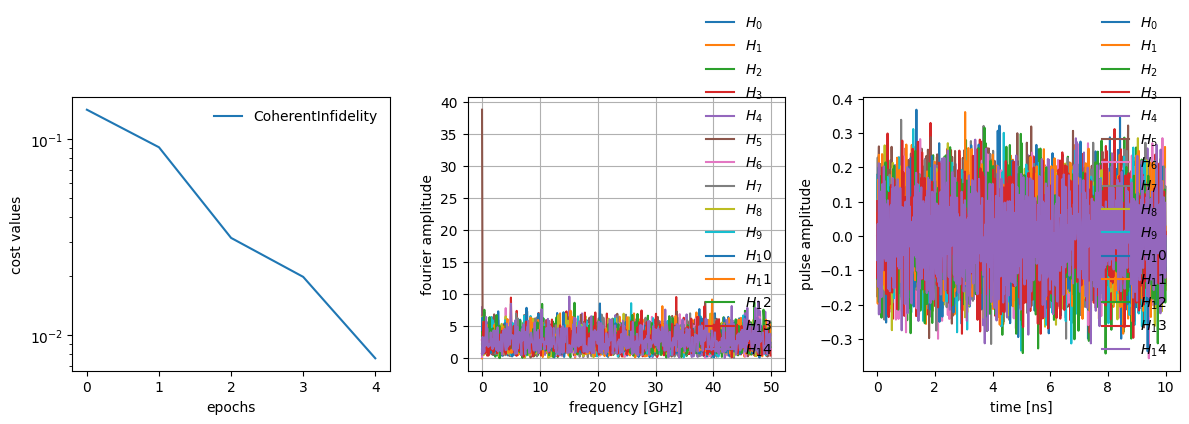

target cost reached for all cost functions
optimization terminated after 4 epochs
average epoch time (excluding jit) of 1.74079 s
max epoch time of 1.76601 s
min epoch time of 1.69306 s


In [33]:
model = ql.sesolve_model(H_pwc, initial_states, tsave)

key = jax.random.PRNGKey(43)
parameters = hyperparams["SEED_AMP"] * jax.random.normal(key, (n_controls, n_timesteps))
print(f"Total parameters: {parameters.size} = {parameters.shape}")

# coherent infidelity averaged all over basis states
cost = ql.cost.coherent_infidelity(target_states=target_states, target_cost=1-hyperparams["TARGET_FIDELITY"])

optimizer = optax.adam(learning_rate=hyperparams["LEARNING_RATE"], b1=0.9, b2=0.999)

optimization_options = {
    'verbose': True,
    'epochs': 1000,
    'plot': True,
    'plot_period': 10,
    # 'batch_initial_parameters': True,
}

dq_options = dq.Options(save_states=True, progress_meter=None)

optimization_params = ql.optimize(parameters, cost, model, optimizer=optimizer, dq_options=dq_options, opt_options=optimization_options)